# Environment setup, DYAMOND access, and IBTrACS ingestion

This notebook does three things:

1. Sets up the Python environment for the SciVis Task 2 workflow.
2. Verifies cloud access to the DYAMOND data through OpenVisus.
3. Downloads, cleans, and saves IBTrACS storm-track data for the DYAMOND time window.

Outputs created here:

- `data/raw/ibtracs/ibtracs.since1980.list.v04r01.csv.gz`
- `data/interim/event_catalog/ibtracs_points_20200120_20210320.parquet`
- `data/interim/event_catalog/ibtracs_storm_summary_20200120_20210320.parquet`

This notebook is intentionally conservative:
- small DYAMOND reads only
- no heavy extraction yet
- clean persistence for later notebooks

In [1]:
import sys
!{sys.executable} -m pip install --upgrade pip

!{sys.executable} -m pip install -r ../requirements.txt

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import pyspark

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("xarray:", xr.__version__)
print("PySpark:", pyspark.__version__)

NumPy: 1.26.4
Pandas: 2.2.2
xarray: 2024.3.0
PySpark: 3.5.1


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

In [4]:
# find proj root 
# should work whether the notebook is run from notebooks or from repo root
def find_project_root(start=None):
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    required = {"data", "src", "notebooks", "outputs", "README.md"}
    for candidate in candidates:
        names = {p.name for p in candidate.iterdir()} if candidate.exists() else set()
        if required.issubset(names):
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory.")
PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"

IBTRACS_RAW_DIR = RAW_DIR / "ibtracs"
EVENT_CATALOG_DIR = INTERIM_DIR / "event_catalog"

for path in [
    IBTRACS_RAW_DIR,
    EVENT_CATALOG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/home/exouser/SciVis_2026')

In [5]:
from src.io.dyamond import (
    DYAMOND_BASE_URL,
    available_variables,
    dataset_summary,
    get_dataset_spec,
    open_dataset,
    read_data,
)
from src.io.ibtracs import (
    download_ibtracs_csv,
    read_ibtracs_csv,
    clean_ibtracs,
    build_storm_summary,
    write_parquet,
)

## Configuration

DYAMOND info:
- DYAMOND is a coupled atmosphere–ocean simulation starting on 2020-01-20 and running for 14 months.
- Task 2 focuses on atmospheric `U, V, P, T` and ocean `Theta, u, v, salt`.

IBTrACS info:
- Use the `since1980` subset by default.
- Trim to the DYAMOND window to keep work focused and to avoid data size issues

In [6]:
CONFIG = {
    "dyamond_time_start": "2020-01-20",
    "dyamond_time_end": "2021-03-20",
    "ibtracs_subset": "since1980",
    "ocean_test_var": "salt",
    "sample_quality": -18,
    "sample_box_ocean": {
        "x": None,
        "y": None,
        "z": [0, 1],
        "time": 0,
    },
}

CONFIG

{'dyamond_time_start': '2020-01-20',
 'dyamond_time_end': '2021-03-20',
 'ibtracs_subset': 'since1980',
 'ocean_test_var': 'salt',
 'sample_quality': -18,
 'sample_box_ocean': {'x': None, 'y': None, 'z': [0, 1], 'time': 0}}

## Verify Environment

In [7]:
import OpenVisus as ov

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("OpenVisus imported successfully")

print("DYAMOND base URL:", DYAMOND_BASE_URL)

vars_available = available_variables()
print("Available DYAMOND variables:", vars_available)

print("Selected test variable:", CONFIG["ocean_test_var"])

Python: 3.10.20
pandas: 2.2.2
numpy: 1.26.4
OpenVisus imported successfully
DYAMOND base URL: https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/
Available DYAMOND variables: ['salt', 'v', 'theta', 'w', 'u']
Selected test variable: salt


## DYAMOND metadata access

This just opens the remote dataset metadata and prints the dataset shape and timestep count. There's no reason to load a massive amount of data for this.

In [8]:
ocean_db = open_dataset(CONFIG["ocean_test_var"])
ocean_meta = dataset_summary(ocean_db)
meta_print = ocean_meta.copy()
ts = meta_print.get("timesteps", [])
meta_print["timesteps"] = {
    "count": len(ts),
    "first": ts[0] if len(ts) > 0 else None,
    "last": ts[-1] if len(ts) > 0 else None,
}
print("Ocean dataset summary")
print(meta_print)

Ocean dataset summary
{'url': 'https://nsdf-climate3-origin.nationalresearchplatform.org:50098/nasa/nsdf/climate3/dyamond/mit_output/llc2160_salt/salt_llc2160_x_y_depth.idx', 'logic_box': ((0, 0, 0), (8640, 6480, 90)), 'shape': (8640, 6480, 90), 'dims': 3, 'timesteps': {'count': 10366, 'first': 0, 'last': 10365}, 'n_timesteps': 10366, 'field_name': 'salt'}


## Small DYAMOND read test

These are tiny on purpose. Just to verify remote access works before doing anything else.

In [9]:
ocean_arr = read_data(
    ocean_db,
    time=CONFIG["sample_box_ocean"]["time"],
    quality=CONFIG["sample_quality"],
    z=CONFIG["sample_box_ocean"]["z"]
)

print("Ocean array shape:", getattr(ocean_arr, "shape", None), "dtype:", getattr(ocean_arr, "dtype", None))

Ocean array shape: (1, 102, 135) dtype: float32


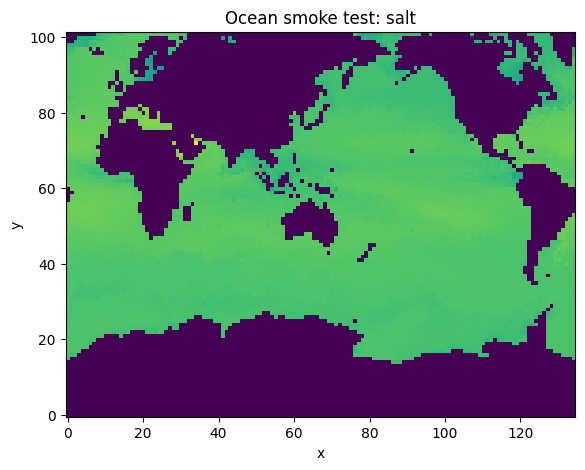

In [10]:
plt.figure(figsize=(8, 5))
plt.imshow(ocean_arr[0], origin="lower")
plt.title(f'Ocean smoke test: {CONFIG["ocean_test_var"]}')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## IBTrACS download

Save the raw compressed CSV under `data/raw/ibtracs/` and keep the original file as is.

In [11]:
ibtracs_raw_path = IBTRACS_RAW_DIR / "ibtracs.since1980.list.v04r01.csv"

if not ibtracs_raw_path.exists():
    ibtracs_raw_path = download_ibtracs_csv(
        output_path=ibtracs_raw_path,
        subset=CONFIG["ibtracs_subset"],
    )

ibtracs_raw_path

PosixPath('/home/exouser/SciVis_2026/data/raw/ibtracs/ibtracs.since1980.list.v04r01.csv')

## IBTrACS ingest and cleaning

Cleaning:
- parse `ISO_TIME` as UTC
- filter to the DYAMOND simulation window
- preserve both `lon_360` and `lon_180`
- turn wind and pressure from USA and WMO fields into `wind_kt` and `pres_mb`
- sort by storm ID and time

In [12]:
ibtracs_raw = read_ibtracs_csv(ibtracs_raw_path)
ibtracs_points = clean_ibtracs(
    ibtracs_raw,
    start=CONFIG["dyamond_time_start"],
    end=CONFIG["dyamond_time_end"],
)

print("Raw rows:", len(ibtracs_raw))
print("Rows in DYAMOND window:", len(ibtracs_points))
print("Unique storms in DYAMOND window:", ibtracs_points["SID"].nunique())

ibtracs_points.head()

Raw rows: 306130
Rows in DYAMOND window: 7681
Unique storms in DYAMOND window: 139


,SID,SEASON,BASIN,NAME,ISO_TIME,LAT,LON,lon_180,lon_360,wind_kt,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
0,2020015S12170,2020,SP,TINO,2020-01-20 00:00:00+00:00,-35.8,199.7,-160.3,199.7,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47,155
1,2020015S12170,2020,SP,TINO,2020-01-20 03:00:00+00:00,-37.7,201.1,-158.9,201.1,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40,150
2,2020015S12170,2020,SP,TINO,2020-01-20 06:00:00+00:00,-39.2,202.3,-157.7,202.3,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28,145
3,2020015S12170,2020,SP,TINO,2020-01-20 09:00:00+00:00,-40.1,203.1,-156.9,203.1,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17,145
4,2020015S12170,2020,SP,TINO,2020-01-20 12:00:00+00:00,-40.6,203.5,-156.5,203.5,-1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13,150


In [13]:
display_cols = ["SID", "SEASON", "BASIN", "NAME", "ISO_TIME", "LAT", "LON", "lon_180", "lon_360", "wind_kt", "pres_mb", "NATURE", "TRACK_TYPE"]

ibtracs_points[display_cols].sample(min(10, len(ibtracs_points)), random_state=42).sort_values(["SID", "ISO_TIME"])

,SID,SEASON,BASIN,NAME,ISO_TIME,LAT,LON,lon_180,lon_360,wind_kt,pres_mb,NATURE,TRACK_TYPE
37,2020019S11063,2020,SI,UNNAMED,2020-01-24 00:00:00+00:00,-28.4,72.7,72.7,72.7,25.0,1004.0,TS,main
1193,2020136N10088,2020,NI,AMPHAN,2020-05-16 15:00:00+00:00,10.8,86.1,86.1,86.1,53.0,990.0,TS,main
1405,2020154N19269,2020,NaN,CRISTOBAL,2020-06-04 06:00:00+00:00,17.9,-91.5,-91.5,268.5,35.0,997.0,TS,main
1575,2020176N10228,2020,EP,BORIS,2020-06-27 18:00:00+00:00,12.3,-141.0,-141.0,219.0,30.0,1007.0,TS,main
3538,2020256N25281,2020,NaN,SALLY,2020-09-16 18:00:00+00:00,31.1,-87.2,-87.2,272.8,60.0,982.0,TS,main
4086,2020272N12257,2020,EP,MARIE,2020-10-06 06:00:00+00:00,21.5,-133.9,-133.9,226.1,45.0,1001.0,TS,main
4466,2020281N14126,2020,WP,LINFA,2020-10-11 12:00:00+00:00,15.0,107.9,107.9,107.9,25.0,1003.0,TS,main
4714,2020291N32305,2020,NaN,EPSILON,2020-10-25 12:00:00+00:00,43.3,-51.8,-51.8,308.2,65.0,964.0,TS,main
4787,2020296N09137,2020,WP,MOLAVE,2020-10-25 21:00:00+00:00,13.1,121.2,121.2,121.2,78.0,979.0,TS,main
5993,2020352S26195,2021,SP,ZAZU,2020-12-19 06:00:00+00:00,-31.2,-156.0,-156.0,204.0,-1.0,<NA>,NR,main


## Storm summary table

Later notebooks can use this to pick storms and build an event catalog.

In [14]:
storm_summary = build_storm_summary(ibtracs_points)

print("Storm summary rows:", len(storm_summary))
storm_summary.head(10)

Storm summary rows: 139


,SID,start_time,end_time,n_points,season,basin,name,nature,track_type,min_lat,max_lat,min_lon_180,max_lon_180,max_wind_kt,min_pres_mb,duration_hours,has_wind,has_pressure
0,2020015S12170,2020-01-20 00:00:00+00:00,2020-01-20 12:00:00+00:00,5,2020,SP,TINO,NR,main,-40.6,-35.8,-160.3,-156.5,-1.0,<NA>,12.0,True,False
1,2020019S11063,2020-01-20 00:00:00+00:00,2020-01-24 06:00:00+00:00,35,2020,SI,UNNAMED,TS,main,-29.8,-11.5,64.5,73.8,45.0,998.0,102.0,True,True
2,2020022S17043,2020-01-22 06:00:00+00:00,2020-01-29 18:00:00+00:00,61,2020,SI,DIANE,DS,main,-35.5,-16.7,43.2,71.6,55.0,985.0,180.0,True,True
3,2020023S19056,2020-01-22 12:00:00+00:00,2020-01-26 12:00:00+00:00,33,2020,SI,ESAMI,DS,main,-28.6,-18.9,56.0,77.0,45.0,991.0,96.0,True,True
4,2020024S14190,2020-01-24 06:00:00+00:00,2020-01-28 18:00:00+00:00,37,2020,SP,UNNAMED,DS,main,-24.5,-14.3,-169.6,-165.9,35.0,1000.0,108.0,True,True
5,2020034S17129,2020-02-03 00:00:00+00:00,2020-02-10 12:00:00+00:00,67,2020,SI,DAMIEN,DS,main,-25.7,-16.0,116.4,129.3,95.0,956.0,180.0,True,True
6,2020034S13063,2020-02-03 06:00:00+00:00,2020-02-15 18:00:00+00:00,101,2020,SI,FRANCISCO,DS,main,-22.1,-13.0,48.3,72.2,45.0,993.0,300.0,True,True
7,2020037S13163,2020-02-06 06:00:00+00:00,2020-02-17 06:00:00+00:00,89,2020,SP,UESI,TS,main,-48.6,-13.1,158.5,164.6,80.0,968.0,264.0,True,True
8,2020045S15075,2020-02-13 18:00:00+00:00,2020-02-23 00:00:00+00:00,75,2020,SI,GABEKILE,MX,main,-24.9,-14.2,66.2,75.7,90.0,969.0,222.0,True,True
9,2020051S13186,2020-02-20 00:00:00+00:00,2020-02-24 06:00:00+00:00,35,2020,SP,VICKY,TS,main,-23.6,-13.1,-174.4,-168.4,45.0,997.0,102.0,True,True


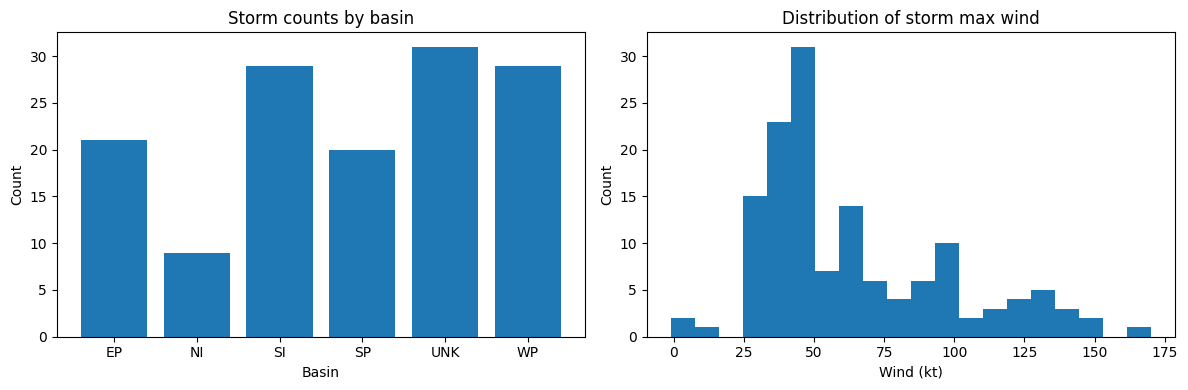

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

basin_counts = (
    storm_summary["basin"]
    .fillna("UNK")
    .value_counts()
    .sort_index()
)
axes[0].bar(basin_counts.index.astype(str), basin_counts.values)
axes[0].set_title("Storm counts by basin")
axes[0].set_xlabel("Basin")
axes[0].set_ylabel("Count")

max_wind = storm_summary["max_wind_kt"].dropna()
axes[1].hist(max_wind, bins=20)
axes[1].set_title("Distribution of storm max wind")
axes[1].set_xlabel("Wind (kt)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Store cleaned outputs

Save two parquet files:
- point-level track records for the DYAMOND period
- storm-level summary records for event selection

In [16]:
points_out = EVENT_CATALOG_DIR / "ibtracs_points.parquet"
summary_out = EVENT_CATALOG_DIR / "ibtracs_storm_summary.parquet"

write_parquet(ibtracs_points, points_out)
write_parquet(storm_summary, summary_out)

print(points_out)
print(summary_out)

/home/exouser/SciVis_2026/data/interim/event_catalog/ibtracs_points.parquet
/home/exouser/SciVis_2026/data/interim/event_catalog/ibtracs_storm_summary.parquet
